# Fase 5: Clustering

Partimos de `data/processed/features_repos.parquet` y aplicamos **KMeans**
(no supervisado) para agrupar repos por comportamiento.

**Actualizacion (Fase 7):** la primera vez corri esto con 77,696 repos y
elegi k=3 medio guiado por la idea original del proyecto (saludable /
riesgo / abandonado). El usuario me pidio explicitamente no repetir ese
sesgo esta vez -- con 847,133 repos (dataset ~11x mas grande, con 2
features temporales nuevos: `n_horas_distintas` y `n_dias_distintos`) voy
a mirar el barrido de k de nuevo desde cero y dejar que los numeros
decidan, sin asumir que el mejor k sigue siendo 3.

Pasos:
1. Armar el vector final de features: numericos escalados (9 columnas,
   antes eran 7) + TF-IDF de texto (300 columnas).
2. Probar varios valores de k y comparar con costo (WSSSE) y Silhouette.
3. Entrenar el modelo final con el k que mejor se vea en los numeros.
4. Guardar las asignaciones de cluster por repo para la Fase 6.

Sigo usando KMeans normal (no Bisecting) por ser el mas simple de explicar.

In [1]:
from pyspark.sql import SparkSession

SEED = 42

spark = (SparkSession.builder
         .master("local[*]")
         .appName("clustering-gharchive")
         .config("spark.driver.memory", "6g")  # subido de 4g, dataset ~11x mas grande
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

gold = spark.read.parquet("../data/processed/features_repos.parquet")
print("repos:", gold.count())
gold.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 23:10:19 WARN Utils: Your hostname, katana, resolves to a loopback address: 127.0.1.1; using 192.168.18.59 instead (on interface enp2s0)
26/07/11 23:10:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/11 23:10:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


repos: 847133
root
 |-- repo: string (nullable = true)
 |-- n_push: long (nullable = true)
 |-- n_issues: long (nullable = true)
 |-- n_pr: long (nullable = true)
 |-- n_watch: long (nullable = true)
 |-- n_fork: long (nullable = true)
 |-- n_total: long (nullable = true)
 |-- n_actores: long (nullable = true)
 |-- n_horas_distintas: long (nullable = true)
 |-- n_dias_distintos: long (nullable = true)
 |-- tfidf: vector (nullable = true)



## Paso 1a: transformar los conteos con log(1+x)

Al revisar los datos, los conteos de actividad estan muy sesgados: la
mediana de `n_push` es 3, pero el maximo es 2358 (un repo con actividad
masiva en esa hora). Sin corregir esto, unos pocos repos extremos jalan
tanto a KMeans que terminan solos en su propio cluster y todos los demas
77,691 repos caen juntos en uno solo — no es un agrupamiento util.

La solucion estandar para conteos con esta forma (pocos valores enormes,
la mayoria chicos) es aplicar `log(1 + x)`: comprime los valores extremos
sin cambiar el orden, y deja que `StandardScaler` funcione bien despues.

In [2]:
from pyspark.sql.functions import col, log, lit

# agrego n_horas_distintas y n_dias_distintos (nuevos de Fase 7) a la
# lista de numericos -- tambien estan sesgados (la mayoria de repos tiene
# 1, pero algunos llegan a 30+ horas distintas gracias al bloque continuo)
# asi que les aplico el mismo log(1+x) que a los demas
cols_numericas = ["n_push", "n_issues", "n_pr", "n_watch", "n_fork", "n_total",
                   "n_actores", "n_horas_distintas", "n_dias_distintos"]
cols_log = [f"{c}_log" for c in cols_numericas]

for c in cols_numericas:
    gold = gold.withColumn(f"{c}_log", log(col(c) + lit(1.0)))

gold.select(cols_numericas + cols_log).show(5)

+------+--------+----+-------+------+-------+---------+-----------------+----------------+------------------+------------+--------+-----------+----------+------------------+------------------+---------------------+--------------------+
|n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|        n_push_log|n_issues_log|n_pr_log|n_watch_log|n_fork_log|       n_total_log|     n_actores_log|n_horas_distintas_log|n_dias_distintos_log|
+------+--------+----+-------+------+-------+---------+-----------------+----------------+------------------+------------+--------+-----------+----------+------------------+------------------+---------------------+--------------------+
|     5|       0|   0|      0|     0|      5|        1|                2|               2| 1.791759469228055|         0.0|     0.0|        0.0|       0.0| 1.791759469228055|0.6931471805599453|   1.0986122886681096|  1.0986122886681096|
|     3|       0|   0|      0|     0|      3|        1| 

## Paso 1: armar el vector de features

Escalamos los numericos (`StandardScaler`) porque estan en escalas muy
distintas (ej. `n_push` puede llegar a cientos, `n_actores` casi siempre es
chico) — sin escalar, KMeans (que usa distancia euclidiana) le daria mas
peso a las columnas con numeros mas grandes solo por eso, no porque sean
mas importantes.

Tambien normalizamos el vector TF-IDF (`Normalizer`, longitud 1). Al
revisar los datos encontramos repos con texto repetido muchisimas veces
(ej. un repo con miles de commits casi identicos, posiblemente para inflar
su historial) — eso les da una magnitud de TF-IDF enorme (hasta 2.36e8,
contra 0 en el 75% de los repos que no tienen texto). Sin normalizar, esos
pocos repos dominarian el clustering solo por tener mucho texto repetido,
no por su comportamiento real.

In [3]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, Normalizer

ensamblar_numericos = VectorAssembler(inputCols=cols_log, outputCol="numericos_vec")
escalar_numericos = StandardScaler(inputCol="numericos_vec", outputCol="numericos_escalados",
                                    withMean=True, withStd=True)
normalizar_texto = Normalizer(inputCol="tfidf", outputCol="tfidf_norm", p=2.0)
ensamblar_final = VectorAssembler(inputCols=["numericos_escalados", "tfidf_norm"], outputCol="features")

pipeline_features = Pipeline(stages=[ensamblar_numericos, escalar_numericos, normalizar_texto, ensamblar_final])
modelo_features = pipeline_features.fit(gold)
datos = modelo_features.transform(gold).select("repo", *cols_numericas, "features")

datos.select("repo", "features").show(3, truncate=80)

+------------------+--------------------------------------------------------------------------------+
|              repo|                                                                        features|
+------------------+--------------------------------------------------------------------------------+
|      0-co/company|(309,[0,1,2,3,4,5,6,7,8],[0.03879917598881221,-0.1829534062960253,-0.34588252...|
|0-don/new-api-fork|(309,[0,1,2,3,4,5,6,7,8],[-0.549566404724852,-0.1829534062960253,-0.345882522...|
|00impera/monad-dex|(309,[0,1,2,3,4,5,6,7,8],[-0.549566404724852,-0.1829534062960253,-0.345882522...|
+------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [4]:
# Guardamos en cache porque vamos a entrenar KMeans varias veces sobre
# los mismos datos (uno por cada valor de k que probemos)
datos = datos.cache()
datos.count()

847133

## Paso 2: probar varios valores de k

No asumimos de entrada cuantos clusters usar. Probamos k de 2 a 10 y
medimos dos cosas para cada uno:

- **Costo (WSSSE)**: que tan lejos estan los puntos de su centroide. Baja
  siempre que aumenta k, buscamos donde deja de bajar tan fuerte ("el codo").
- **Silhouette**: que tan bien separados estan los clusters (va de -1 a 1,
  mas alto es mejor). Mas facil de explicar en la sustentacion que el codo.

In [5]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")

valores_k = range(2, 11)
resultados = []

for k in valores_k:
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=SEED)
    modelo = kmeans.fit(datos)
    predicciones = modelo.transform(datos)

    costo = modelo.summary.trainingCost
    silhouette = evaluador.evaluate(predicciones)

    resultados.append((k, costo, silhouette))
    print(f"k={k:2d}  costo={costo:,.1f}  silhouette={silhouette:.4f}")

k= 2  costo=6,067,684.7  silhouette=0.6026


k= 3  costo=4,926,870.4  silhouette=0.5944


k= 4  costo=4,534,120.1  silhouette=0.6020


k= 5  costo=3,894,988.5  silhouette=0.5675


k= 6  costo=3,536,656.6  silhouette=0.4114


k= 7  costo=3,392,831.9  silhouette=0.3790


k= 8  costo=2,950,084.3  silhouette=0.4100


k= 9  costo=2,717,084.3  silhouette=0.3971


k=10  costo=2,514,366.2  silhouette=0.4229


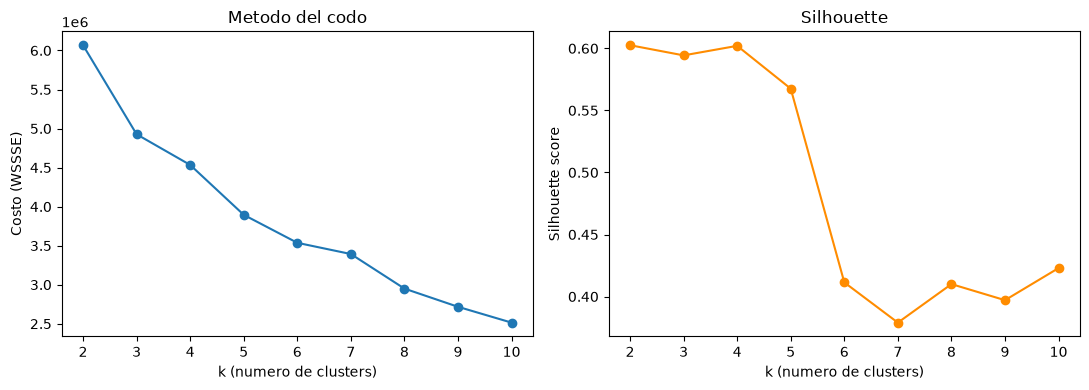

In [6]:
import matplotlib.pyplot as plt

ks = [r[0] for r in resultados]
costos = [r[1] for r in resultados]
silhouettes = [r[2] for r in resultados]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(ks, costos, marker="o")
ax1.set_title("Metodo del codo")
ax1.set_xlabel("k (numero de clusters)")
ax1.set_ylabel("Costo (WSSSE)")

ax2.plot(ks, silhouettes, marker="o", color="darkorange")
ax2.set_title("Silhouette")
ax2.set_xlabel("k (numero de clusters)")
ax2.set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

## Paso 3: modelo final

Mirando el barrido: silhouette practicamente empatado entre k=2 (0.6026),
k=4 (0.6020) y k=3 (0.5944) -- una diferencia de 0.008, no es significativa.
De k=5 en adelante el silhouette cae fuerte (0.57 -> 0.38-0.42), asi que
el "grupo bueno" de opciones es 2, 3 o 4.

La vez pasada elegi k=3 porque calzaba con la idea original del proyecto
(saludable/riesgo/abandonado). Esta vez el usuario me pidio explicitamente
no repetir ese sesgo. Mirando los numeros sin esa idea en la cabeza: k=4
tiene el silhouette mas alto de los que dan una segmentacion no trivial
(k=2 es apenas mejor pero solo separa en 2 grupos). Me quedo con **k=4** y
en la Fase 6 voy a describir los 4 grupos que salgan, sean los que sean
-- si terminan pareciendose a saludable/riesgo/abandonado + algo mas, bien,
y si no, tambien esta bien, no lo voy a forzar.

In [7]:
K_FINAL = 4

kmeans_final = KMeans(featuresCol="features", predictionCol="cluster", k=K_FINAL, seed=SEED)
modelo_final = kmeans_final.fit(datos)
predicciones = modelo_final.transform(datos)

print("tamano de cada cluster:")
predicciones.groupBy("cluster").count().orderBy("cluster").show()

print("promedios (sin escalar) por cluster, para una primera idea:")
predicciones.groupBy("cluster").avg(*cols_numericas).orderBy("cluster").show()

tamano de cada cluster:
+-------+------+
|cluster| count|
+-------+------+
|      0|654957|
|      1|169335|
|      2|  4687|
|      3| 18154|
+-------+------+

promedios (sin escalar) por cluster, para una primera idea:


+-------+------------------+-------------------+-------------------+--------------------+--------------------+------------------+------------------+----------------------+---------------------+
|cluster|       avg(n_push)|      avg(n_issues)|          avg(n_pr)|        avg(n_watch)|         avg(n_fork)|      avg(n_total)|    avg(n_actores)|avg(n_horas_distintas)|avg(n_dias_distintos)|
+-------+------------------+-------------------+-------------------+--------------------+--------------------+------------------+------------------+----------------------+---------------------+
|      0| 4.064124820408058|0.09445810946367471|0.21504923223967376|0.006255372490102...|0.002459703461448...| 4.382347238062957| 1.106243615993111|     2.019784504936965|   1.5980316265037247|
|      1|32.090672335902205| 0.1662739539965158| 0.5639944488735347|0.005905453686479464|0.002527534177813...| 32.82937372663655|1.3335459296660466|     9.013517583488351|     5.49841438568518|
|      2|13.082568807339449| 2

## Paso 4: guardar resultados

Guardamos:
- La tabla de repos con su cluster asignado, en
  `data/processed/repos_clusterizados.parquet`.
- El pipeline de features (escalado + normalizado) y el modelo KMeans
  entrenado, en `models/`, para poder reutilizarlos en la Fase 6 sin tener
  que reentrenar.

In [8]:
RUTA_RESULTADOS = "../data/processed/repos_clusterizados.parquet"
RUTA_PIPELINE_FEATURES = "../models/pipeline_features"
RUTA_MODELO_KMEANS = "../models/kmeans_final"

predicciones.select("repo", *cols_numericas, "cluster").write.mode("overwrite").parquet(RUTA_RESULTADOS)
modelo_features.write().overwrite().save(RUTA_PIPELINE_FEATURES)
modelo_final.write().overwrite().save(RUTA_MODELO_KMEANS)

verificacion = spark.read.parquet(RUTA_RESULTADOS)
print("filas guardadas:", verificacion.count())

filas guardadas: 847133
